In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline

import math as m
import math


In [2]:
# Read datasets and set the index to be the date
df1 = pd.read_csv('../datasets/TX-Data/met_station/met_1.dat', sep=",", parse_dates=["Date"], index_col="Date")



In [4]:
# cite from https://stackoverflow.com/questions/31142181/calculating-julian-date-in-python
import datetime
import math

def get_julian_datetime(date):

    # Ensure correct format
    if not isinstance(date, datetime.datetime):
        raise TypeError('Invalid type for parameter "date" - expecting datetime')
    elif date.year < 1801 or date.year > 2099:
        raise ValueError('Datetime must be between year 1801 and 2099')

    # Perform the calculation
    julian_datetime = 367 * date.year - int((7 * (date.year + int((date.month + 9) / 12.0))) / 4.0) + int(
        (275 * date.month) / 9.0) + date.day + 1721013.5 + (
                          date.hour + date.minute / 60.0 + date.second / math.pow(60,
                                                                                  2)) / 24.0 - 0.5 * math.copysign(
        1, 100 * date.year + date.month - 190002.5) + 0.5

    return julian_datetime


In [86]:
def get_sunlight_time(Longtitude,Latitude,Time_Zone):
    time =df1.index.to_list()
    Sunlight_Duration_list=[]
    Sunrise_Time_list=[]
    Sunset_Time_list=[]

    for t in time:
        Julian_Day = get_julian_datetime(t)
        Julian_Century = (Julian_Day -2451545) / 36525
        #Julian Century 
        Julian_Century = (Julian_Day -2451545) / 36525
        #Geom Mean Anom Sun (deg) 
        Anom_Sun=357.52911+Julian_Century*(35999.05029 - 0.0001537*Julian_Century)
        #Geom Mean Long Sun (deg) 
        Long_Sun = np.mod(280.46646+Julian_Century*(36000.76983 + Julian_Century*0.0003032),360)
        # Eccent Earth Orbit
        Eccent_Earth_Orbit =0.016708634-Julian_Century*(0.000042037+0.0000001267*Julian_Century)
        #Sun Eq of Ctr 
        Sun_Eq = m.sin(m.radians(Anom_Sun))*(1.914602-Julian_Century*(0.004817+0.000014*Julian_Century)) \
        +m.sin(m.radians(2*Anom_Sun))*(0.019993-0.000101*Julian_Century)+m.sin(m.radians(3*Anom_Sun))*0.000289
        #Sun True Long (deg)
        Sun_True_Long = Sun_Eq + Long_Sun
        #Sun App Long (deg)
        Sun_App_Long = Sun_True_Long-0.00569-0.00478*m.sin(m.radians(125.04-1934.136*Julian_Century))
        # Mean Obliq Ecliptic (deg)
        Mean_O_E=23+(26+((21.448-Julian_Century*(46.815+Julian_Century*(0.00059-Julian_Century*0.001813))))/60)/60
        # Obliq Corr (deg)
        Obliq_Corr=Mean_O_E+0.00256*m.cos(m.radians(125.04-1934.136*Julian_Century))
        # Sun Declin (deg)
        Sun_Declin=m.degrees(m.asin(m.sin(m.radians(Obliq_Corr))*m.sin(m.radians(Sun_App_Long))))
        # HA Sunrise (deg)
        HA_Sunrise=m.degrees(m.acos(m.cos(m.radians(90.833))/(m.cos(m.radians(Latitude))*m.cos(m.radians(Sun_Declin))) \
        -m.tan(m.radians(Latitude))*m.tan(m.radians(Sun_Declin))))
        #vary_y
        vary_y=m.tan(m.radians(Obliq_Corr/2))*m.tan(m.radians(Obliq_Corr/2))
        #Eq of Time (minutes)
        Eq_of_Time =4*m.degrees(vary_y*m.sin(2*m.radians(Long_Sun))-2*Eccent_Earth_Orbit*m.sin(m.radians(Anom_Sun))+4*Eccent_Earth_Orbit*vary_y*m.sin(m.radians(Anom_Sun))*m.cos(2*m.radians(Long_Sun))-0.5*vary_y*vary_y*m.sin(4*m.radians(Long_Sun))-1.25*Eccent_Earth_Orbit*Eccent_Earth_Orbit*m.sin(2*m.radians(Anom_Sun)))



        #Solar Noon (LST)
        Solar_Noon=(720-4*Longtitude-Eq_of_Time+Time_Zone*60)/1440
        # Solar_Noon = pd.to_timedelta(Solar_Noon_min, unit='m')

        #Sunrise Time (LST)
        Sunrise_Time_min=Solar_Noon-HA_Sunrise*4/1440
        Sunrise_Time = pd.to_timedelta(Sunrise_Time_min*1440, unit='m')
        Sunrise_Time_list.append(Sunrise_Time)

        #Sunset Time (LST)
        Sunset_Time_min=Solar_Noon+HA_Sunrise*4/1440
        Sunset_Time = pd.to_timedelta(Sunset_Time_min*1440, unit='m')
        Sunset_Time_list.append(Sunset_Time)

        #Sunlight Duration (minutes)
        Sunlight_Duration=(Sunset_Time_min -Sunrise_Time_min)*1440
        Sunlight_Duration_list.append(Sunlight_Duration)
    return Sunrise_Time_list, Sunset_Time_list, Sunlight_Duration_list

In [90]:
# Austin Longtitude:-97.733330 latitude:30.266666 Austin time zone: -6  (change to location you want)
Longtitude = -97.733330
Latitude = 30.266666
Time_Zone = -6
Sunrise_Time_list, Sunset_Time_list, Sunlight_Duration_list = get_sunlight_time(Longtitude,Latitude,Time_Zone)
# create a dataframe
df = pd.DataFrame()
df['Sunrise Time'] = Sunrise_Time_list
df['Sunset Time'] = Sunset_Time_list
df['Sunlight Duration(mins)']=Sunlight_Duration_list
df=df.set_index(pd.Series(time))
df

,Sunrise Time,Sunset Time,Sunlight Duration(mins)
2014-10-01 00:00:00,0 days 06:24:06.546200880,0 days 18:17:28.757773860,713.370193
2014-10-01 01:00:00,0 days 06:24:07.997427120,0 days 18:17:25.675079040,713.294628
2014-10-01 02:00:00,0 days 06:24:09.449051520,0 days 18:17:22.592936520,713.219065
2014-10-01 03:00:00,0 days 06:24:10.901075100,0 days 18:17:19.511348460,713.143505
2014-10-01 04:00:00,0 days 06:24:12.353498700,0 days 18:17:16.430316900,713.067947
...,...,...,...
2021-08-31 20:00:00,0 days 06:07:33.386103600,0 days 18:54:37.432705380,767.067443
2021-08-31 21:00:00,0 days 06:07:34.777883100,0 days 18:54:34.465589760,766.994795
2021-08-31 22:00:00,0 days 06:07:36.169481160,0 days 18:54:31.497617340,766.922136
2021-08-31 23:00:00,0 days 06:07:37.560898320,0 days 18:54:28.528790160,766.849465


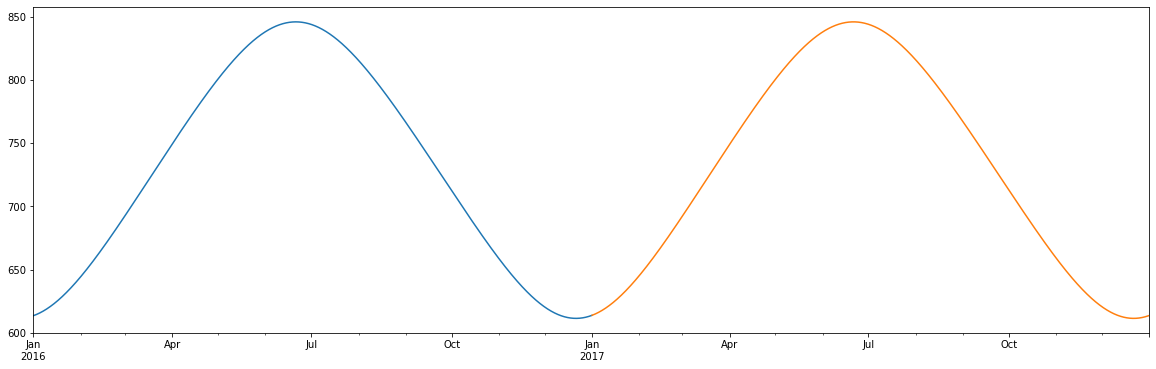

In [89]:
SD = df.get('Sunlight Duration')
years = [str(yr) for yr in range(2016, 2018)]

for yr in years:        
    df_yr = SD[yr]
    df_yr.plot(figsize=(20,6))